In [22]:
%run Packages_and_Functions.ipynb
# %run Graph_Generators.ipynb
# %run Metric_Repair_Algorithms.ipynb
import scipy.special
from random import randrange


In [79]:
## Joon code

def count_shortest_paths_bfs(G, source):
    """ Computes shortest path distances and counts using BFS. """
    dist = {node: float('inf') for node in G.vertices(sort=True)}
    count = {node: 0 for node in G.vertices(sort=True)}
    
    dist[source] = 0
    count[source] = 1
    queue = [source]

    for u in queue:
        for v in G.neighbors(u):
            if dist[v] == float('inf'):  # First time visiting
                dist[v] = dist[u] + 1
                count[v] = count[u]
                queue.append(v)
            elif dist[v] == dist[u] + 1:  # Another shortest path
                count[v] += count[u]

    return dist, count


def sample_shortest_path(G, source, target):
    """ Uniformly samples a shortest path from source to target in an unweighted graph. """
    dist, count = count_shortest_paths_bfs(G, source)

    if dist[target] == float('inf'):
        return None, dist[target]  # No path exists

    path = [target]
    current = target

    while current != source:
        predecessors = [v for v in G.neighbors(current) if dist[v] == dist[current] - 1]
        weights = [count[v] for v in predecessors]
        current = random.choices(predecessors, weights=weights)[0]
        path.append(current)

    return path[::-1], dist[target]  # Reverse for correct order


def sample_geodesic_triangle(G,p,q,r):
    pq, c = sample_shortest_path(G,p,q)
    qr, a = sample_shortest_path(G,q,r)
    rp, b = sample_shortest_path(G,r,p)
    return pq, qr, rp, c, a, b


def compute_triangle_thinness(D,pq,qr,rp,c,a,b):
    zeta = 0.0
    # a = len(qr) - 1
    # b = len(rp) - 1
    # c = len(pq) - 1
    for i in range(a):
        if 2*i <= a+c-b:
            zeta = max(zeta, D[qr[i], pq[c-i]])
        if 2*i >= a+c-b:
            zeta = max(zeta, D[qr[i], rp[a-i]])
    for j in range(c):
        if 2*j <= b+c-a:
            zeta = max(zeta, D[pq[j], rp[b-j]])
    return zeta

def compute_triangle_slimness(D,pq,qr,rp,c,a,b):
    delta = 0.0
    for v in pq:
        proj_dist = c
        for w in qr+rp:
            proj_dist = min(proj_dist, D[v,w])
        delta = max(delta, proj_dist)
    for v in qr:
        proj_dist = a
        for w in pq+rp:
            proj_dist = min(proj_dist, D[v,w])
        delta = max(delta, proj_dist)
    for v in rp:
        proj_dist = b
        for w in qr+pq:
            proj_dist = min(proj_dist, D[v,w])
        delta = max(delta, proj_dist)
    return delta

def compute_triangle_minsize(D,pq,qr,rp,c,a,b):
    eta = float('inf')
    best_triplet = None
    for x,y,z in product(pq,qr,rp):
        max_dist = max(D[x,y], D[y,z], D[z,x])
        if max_dist < eta:
            eta = max_dist
            best_triplet = (x,y,z)
    return eta

def compute_triangle_insize(D,pq,qr,rp,c,a,b):
    # a = len(qr) - 1
    # b = len(rp) - 1
    # c = len(pq) - 1
    if (a+c-b)%2 == 1:
        iota = float('inf')
        i = int((b+c-a-1)/2)
        j = int((a+c-b-1)/2)
        k = int((a+b-c-1)/2)
        X = [pq[i], pq[i+1]]
        Y = [qr[j], qr[j+1]]
        Z = [rp[k], rp[k+1]]
        for x,y,z in product(X,Y,Z):
            max_dist = max(D[x,y], D[y,z], D[z,x])
            if max_dist < iota:
                iota = max_dist
        return iota + 1
    else:
        x = pq[int((b+c-a)/2)]
        y = qr[int((a+c-b)/2)]
        z = rp[int((a+b-c)/2)]
        return max(D[x,y], D[y,z], D[z,x])


In [102]:
## Compute average slimness of G(n,p) and Gamma(n,p)
n = 100
reps = 10
reps_triangles = 10
Alpha = np.linspace(0.1,0.9,10)
p = lambda x: np.power(n,-x)
results_slimness = np.zeros((len(Alpha),reps))
results_slimness_by_weight = np.zeros((len(Alpha),reps))
for k,alpha in enumerate(Alpha):
    for rep in range(reps):
        print("alpha = ", alpha, ", rep = ", rep)
        G = random_geometric_weighted_graph(n,p(alpha)) 
        H = get_subdivided_graph(G) ## Not to be confused - this is the weighted graph for BFS purposes
        for t in range(reps_triangles):
            print("   triangle rep = ", t)
            x,y,z = random.sample(G.vertices(sort=True),3)
            xy, yz, zx, c, a, b = sample_geodesic_triangle(G,x,y,z)
            D = G.distance_matrix()
            # print(k,r,)
            results_slimness[k,rep] += compute_triangle_slimness(D,xy,yz,zx,c,a,b)/reps_triangles # this is slimness of G, without weights
            # results_slimness[k,r] += 1

            xy, yz, zx, c, a, b = sample_geodesic_triangle(H,x,y,z) #when working with H, it takes into consideration the weights in G - as we subdivide edges according to weights
            D = H.distance_matrix()
            results_slimness_by_weight[k,rep] += compute_triangle_slimness(D,xy,yz,zx,c,a,b)/reps_triangles
        

alpha =  0.1 , rep =  0
   triangle rep =  0
   triangle rep =  1
   triangle rep =  2
   triangle rep =  3
   triangle rep =  4
   triangle rep =  5
   triangle rep =  6
   triangle rep =  7
   triangle rep =  8
   triangle rep =  9
alpha =  0.1 , rep =  1
   triangle rep =  0
   triangle rep =  1
   triangle rep =  2
   triangle rep =  3
   triangle rep =  4
   triangle rep =  5
   triangle rep =  6
   triangle rep =  7
   triangle rep =  8
   triangle rep =  9
alpha =  0.1 , rep =  2
   triangle rep =  0
   triangle rep =  1
   triangle rep =  2
   triangle rep =  3
   triangle rep =  4
   triangle rep =  5
   triangle rep =  6
   triangle rep =  7
   triangle rep =  8
   triangle rep =  9
alpha =  0.1 , rep =  3
   triangle rep =  0
   triangle rep =  1
   triangle rep =  2
   triangle rep =  3
   triangle rep =  4
   triangle rep =  5
   triangle rep =  6
   triangle rep =  7
   triangle rep =  8
   triangle rep =  9
alpha =  0.1 , rep =  4
   triangle rep =  0
   triangle rep =  

IndexError: matrix index out of range

In [ ]:
G = random_geometric_weighted_graph(5,.5)


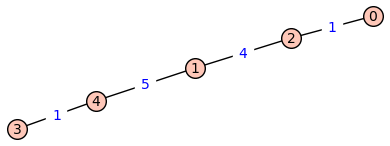

In [86]:
G.show(edge_labels=1)
G.weighted(True)

In [88]:
G.distance(0,3,by_weight=1)

11